In [4]:
import os, sys, imaplib
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import _cm
import numpy as np


In [5]:
## data :
path_df=r"../results\vol1\vol1-combined_table-index_theme_notice.csv"
df=pd.read_csv(path_df)
print(df.shape)
print(df.columns.to_list())

(622, 14)
['title_theme', 'title_index', 'author', 'theme', 'cycle', 'collection', 'mss_ff', 'mss', 'ff', 'page', 'mss_index', 'material_class', 'size_class', 'cent_i']


In [6]:
display(df.head())

,title_theme,title_index,author,theme,cycle,collection,mss_ff,mss,ff,page,mss_index,material_class,size_class,cent_i
0,heroica,heroica,flavius philostratus,classical romances,cycle of troy,royal,16. c. xxiii. ff. 2-69 b,16. c. xxiii.,ff. 2-69 b,1,royal 16. c. xxiii. ff. 2-69 b,vellum,quarto,15.0
1,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,royal,16. c. iv. a. b.,16. c. iv. a. b.,NaN,2,royal 16. c. iv. a. b.,paper,quarto,16.0
2,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,royal,16. d. iii. a. b.,16. d. iii. a. b.,NaN,2,royal 16. d. iii. a. b.,paper,NaN,6.0
3,iliaca,iliaca,joannes tzetzes,classical romances,cycle of troy,harley,harley 5662. ff. 1-56,harley 5662.,ff. 1-56,2,harley 5662. ff. 1-56,paper,quarto,15.0
4,dictys cretensis,dictys cretensis,NaN,classical romances,cycle of troy,harley,harley 3514,harley 3514,NaN,9,harley 3514,vellum,octavo,15.0


In [7]:
df.value_counts(dropna=False)

title_theme         title_index                     author               theme                           cycle  collection  mss_ff                        mss                 ff               page  mss_index                              material_class  size_class  cent_i
athis et profilias  roman d'athis et profilas       NaN                  appendix                        NaN    additional  add. 16,441                   add. 16,441         NaN              929   additional add. 16,441                 vellum          quarto      14.0      2
havelok             havelok                         geffrei gaimar       british and english traditions  NaN    royal       13. a. xxi. ff. 113-117 b     13. a. xxi.         ff. 113-117 b    423   royal 13. a. xxi. ff. 113-117 b        vellum          quarto      14.0      2
                                                    NaN                  appendix                        NaN    royal       13. a. xxi. ff. 113-117 b     13. a. xxi.         ff.

In [8]:
# mss==mss_index
df[['mss','mss_index']].value_counts()

mss                mss_index                             
8. b. iv.          royal 8. b. iv. ff. 19-71 b               4
add. 18,217        additional add. 18,217                    4
add. 16,441        additional add. 16,441                    4
add. 30864         additional add. 30864                     4
add. 17,084        additional add. 17,084                    4
                                                            ..
13. c. xii.        royal 13. c. xii. ff. 6-32 b              1
                   royal 13. c. xii. ff. 82-109 b            1
13. d. i.          royal 13. d. i. ff. 175-212 b             1
13. e. ix.         royal 13. e. ix. ff. 27                   1
vespasian b. xxv.  cotton vespasian b. xxv. ff. 117 b-123    1
Name: count, Length: 504, dtype: int64

In [9]:
df_texts=df.drop_duplicates(subset=['title_index'])
print(len(df), len(df_texts))
df_mss=df.drop_duplicates(subset=['mss'])
print(len(df),len(df_mss))

622 228
622 394


In [10]:
df=df.dropna(subset=['mss'])
print(len(df))
df.mss.value_counts(dropna=False)

587


mss
add. 27879          14
caligula a. ii.     10
15. e. vi.           9
add. 4859.           7
caligula b. vii.     6
                    ..
16. c. xxiii.        1
egerton 2515         1
add. 4875.           1
harley 6148.         1
lansdowne 214.       1
Name: count, Length: 393, dtype: int64

In [11]:
df["coll_mss"]=df.apply(lambda row: row["collection"]+" "+row["mss"] if not row["mss"].startswith('add') and not row["mss"].startswith('lansdowne') else row["mss"], axis=1)

In [12]:
df['coll_mss'].value_counts(dropna=False)


coll_mss
add. 27879                 14
cotton caligula a. ii.     10
royal 15. e. vi.            9
add. 4859.                  7
cotton caligula b. vii.     6
                           ..
royal 16. c. xxiii.         1
egerton egerton 2515        1
add. 4875.                  1
harley harley 6148.         1
lansdowne 214.              1
Name: count, Length: 393, dtype: int64

## desc:

title_index
turpin's chronicle             36
alexandreis                    32
historia regum britanniae      32
alexander the great            20
titus and vespasian            18
dares phrygius                 17
historia trojana               17
lancelot du lac                13
roman de la rose               13
sydrac and boctus              11
prophecy of the tenth sibyl    11
apollonius of tyre             10
merlin                         10
voeux du paon                  10
prophecies of merlin            9
Name: count, dtype: int64


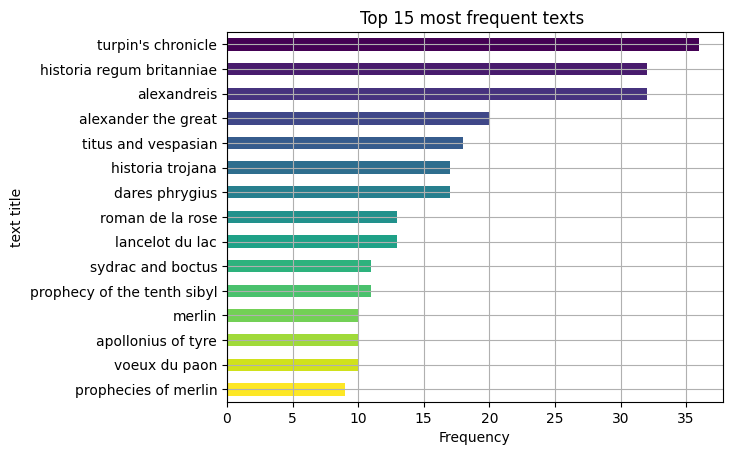

In [13]:
N=15

top_n = df['title_index'].value_counts().head(N)
print(top_n)
values = top_n.sort_values() 
colors = plt.cm.viridis(np.linspace(1, 0, len(values)))

values.plot(kind='barh',color=colors)

plt.title(f"Top {N} most frequent texts ")
plt.xlabel("Frequency")
plt.ylabel('text title')
plt.grid()
plt.show()

collection
additional    110
harley         89
royal          73
cotton         61
arundel        20
sloane         16
lansdowne      13
egerton         6
burney          5
Name: count, dtype: int64


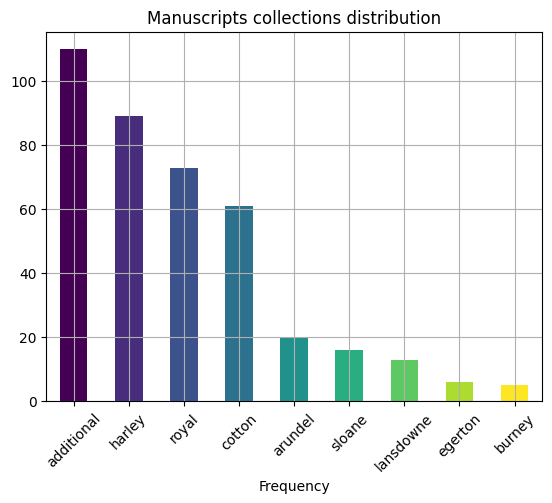

In [14]:
N=15
top_n = df_mss['collection'].value_counts().head(N)
values = top_n.sort_values(ascending=False) 
print(values)
colors = plt.cm.viridis(np.linspace(0, 1, len(values)))
values.plot(kind='bar',color=colors)

plt.title(f"Manuscripts collections distribution")
plt.xlabel("Frequency")
plt.grid()
plt.xticks(rotation=45)
plt.show()



theme
british and english traditions      50
classical romances                  31
miscellaneous romance               29
french traditions                   21
allegorical and didactic romance     4
appendix                             4
Name: count, dtype: int64


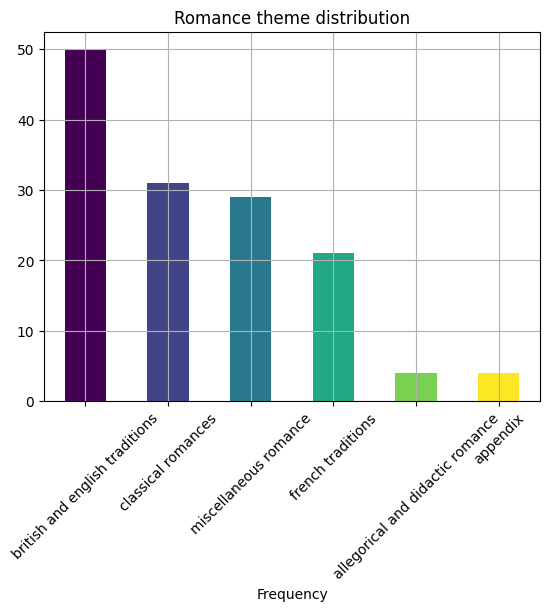

In [15]:

top_n = df_texts['theme'].value_counts()
values = top_n.sort_values(ascending=False) 
print(values)
colors = plt.cm.viridis(np.linspace(0, 1, len(values)))

values.plot(kind='bar',color=colors)

plt.title(f"Romance theme distribution")
plt.xlabel("Frequency")
plt.grid()
plt.xticks(rotation=45)
plt.show()


coll_mss
add. 27879                 14
cotton caligula a. ii.     10
royal 15. e. vi.            9
add. 4859.                  7
cotton caligula b. vii.     6
cotton titus a. xix.        5
add. 31042                  5
royal 13. a. xxi.           5
harley harley 6340          4
cotton nero a. xi.          4
harley harley 4745          4
royal 15. a. x.             4
royal 8. b. iv.             4
burney burney 312           4
add. 4857.                  4
Name: count, dtype: int64


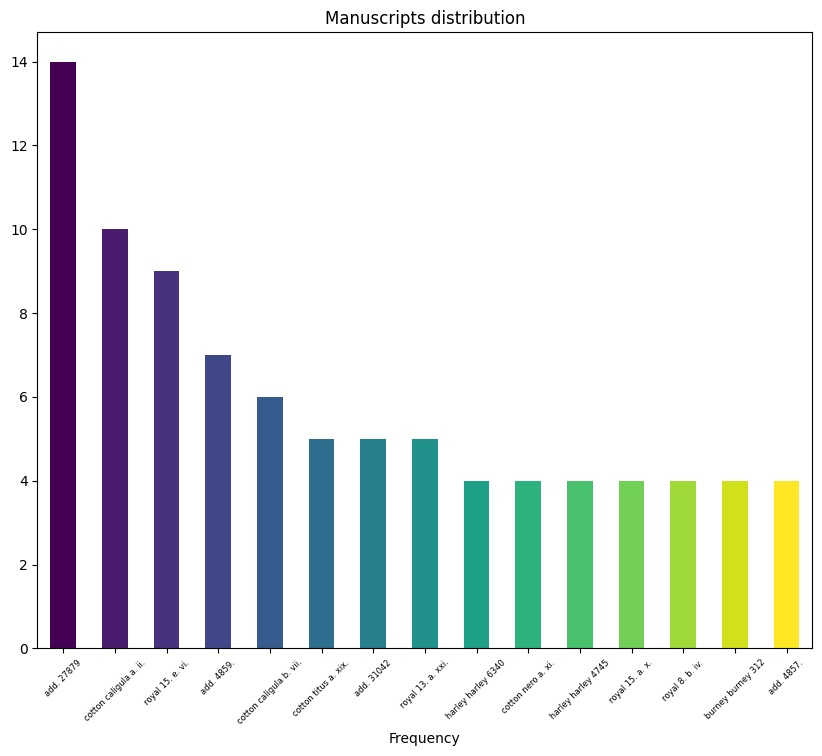

In [16]:
plt.figure(figsize=(10, 8))

N=15
top_n = df['coll_mss'].value_counts().head(N)
values = top_n.sort_values(ascending=False) 
print(values)
colors = plt.cm.viridis(np.linspace(0, 1, len(values)))

values.plot(kind='bar',color=colors)

plt.title(f"Manuscripts distribution")
plt.xlabel("Frequency")
plt.xticks(rotation=45, fontsize=6)
plt.show()

In [17]:
counts=df.groupby('collection')['mss'].apply(list)
print(counts)

# N=15
# top_n = df['coll_mss'].value_counts().head(N)
# values = top_n.sort_values(ascending=False) 
# print(values)
# colors = plt.cm.viridis(np.linspace(0, 1, len(values)))

# values.plot(kind='bar',color=colors)

# plt.title(f"Manuscripts distribution")
# plt.xlabel("Frequency")
# plt.xticks(rotation=45, fontsize=6)
# plt.show()

collection
additional    [add. 15,429, add. 10,094., add. 15,042, add. ...
arundel       [arundel 6, arundel 174, arundel 99, arundel 1...
burney        [burney 170, burney 216., burney 280., burney ...
cotton        [caligula b. vii., vitellius a. xiii., vitelli...
egerton       [egerton 810, egerton 989, egerton 881, egerto...
harley        [harley 5662., harley 3514, harley 641., harle...
lansdowne     [lansdowne 229., lansdowne 762., lansdowne 757...
royal         [16. c. xxiii., 16. c. iv. a. b., 16. d. iii. ...
sloane        [sloane 1619, sloane 1619, sloane 2233, sloane...
Name: mss, dtype: object


In [18]:
# N=15
# top_n = df['mss'].value_counts().head(N)
# values = top_n.sort_values(ascending=False) 
# print(values)
# colors = plt.cm.viridis(np.linspace(0, 1, len(values)))

# values.plot(kind='bar',color=colors)

# plt.title(f"Manuscripts distribution")
# plt.xlabel("Frequency")
# plt.xticks(rotation=45)
# plt.show()


material_class
vellum    195
paper     112
NaN        87
Name: count, dtype: int64


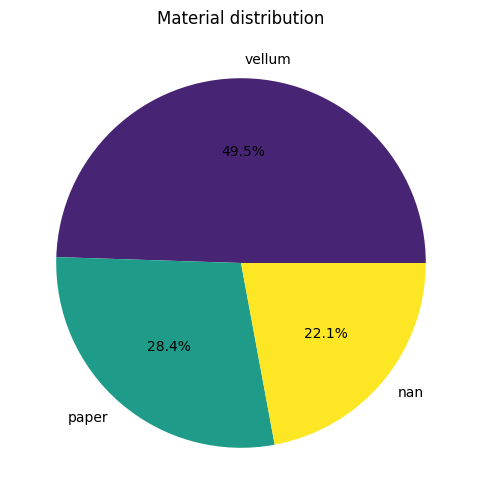

In [19]:
# ## barplot
# df['material_class']=df['material_class'].fillna("unknown")
# top_n = df['material_class'].value_counts().head(N)
# values = top_n.sort_values() 
# colors = plt.cm.viridis(np.linspace(1, 0, len(values)))

# values.plot(kind='bar',color=colors)

# plt.title(f"Material distribution")
# plt.xlabel("Frequency")
# plt.show()

## pie
counts=df_mss['material_class'].value_counts(dropna=False)
print(counts)
colors = plt.cm.viridis(np.linspace(0.1, 1, len(counts)))
# colors=plt.cm.tab20.colors

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors = colors)
plt.title("Material distribution")
plt.show()

size_class
folio      138
quarto     126
unknown     97
octavo      33
Name: count, dtype: int64


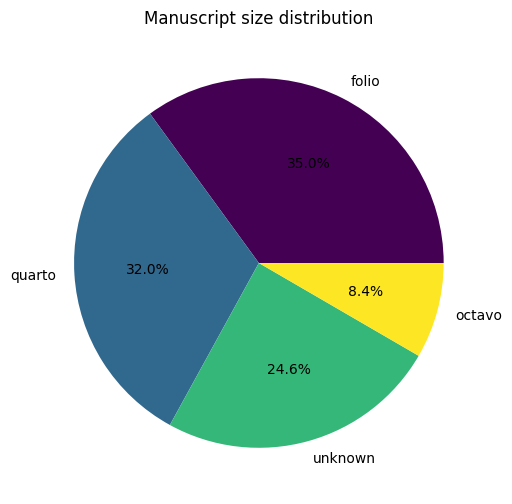

In [20]:
df=df_mss.copy()
df["size_class"]=df["size_class"].fillna('unknown')

print(df['size_class'].value_counts(dropna=False))
counts = df['size_class'].value_counts(dropna=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))
# colors=plt.cm.tab20.colors

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors = colors)
plt.title("Manuscript size distribution")
plt.show()

cent_s
15e    68
14e    33
5e     14
1e     12
16e    10
18e     9
4e      7
17e     6
19e     6
6e      2
12e     2
13e     2
8e      1
11e     1
2e      1
Name: count, dtype: int64


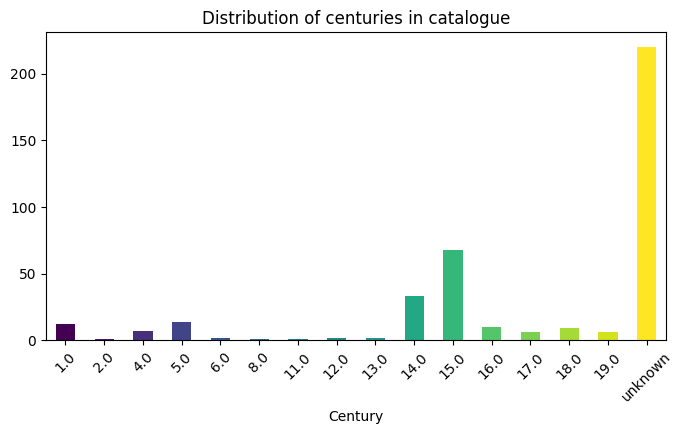

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=df_mss.copy()
df['cent_s'] = df['cent_i'].apply(
    lambda x: f"{int(x)}e" if pd.notna(x) and x!="unknown" else "unknown"
)

counts = df['cent_s'].value_counts()

unknown = counts[counts.index == "unknown"]
known = counts[counts.index != "unknown"]

known_sorted = known.copy()
print(known_sorted)

known_sorted.index = known_sorted.index.str.replace("e", "").astype(float)
known_sorted = known_sorted.sort_index()

final = pd.concat([known_sorted, unknown])

colors = plt.cm.viridis(np.linspace(0, 1, len(final)))


final.plot(kind='bar', color=colors, figsize=(8,4))

plt.title("Distribution of centuries in catalogue")
plt.xlabel("Century")
plt.xticks(rotation=45)
plt.show()

In [22]:
path_df=r"../results\vol1\vol1-combined_table-index_theme_notice-clean1.csv"
df.to_csv(path_df, index=False)


In [23]:
# Avec les nouvelles données

file = '../corpus/curated/extracted_notices.json'
df = pd.read_json(file)
df

,work_name,manuscript,full_notice_text,material,date,format,subject,keywords
0,Heroica,16. C. xxiii. ff. 2-69 b,**Royal 16. C. xxiii. ff. 2–69 b.**\n\nVellum;...,vellum,15th century,quarto (4to),A Greek dialogue by Flavius Philostratus discu...,"[Greek literature, Trojan War, dialogue, heroi..."
1,Iliaca,16. C. iv. A. B.,"## Royal 16. C. iv. A. B.\n\nPaper; two vols.,...",paper,1560-1565,quarto,A Greek poem titled 'Iliaca' by Joannes Tzetze...,"[Byzantine literature, Trojan War, Joannes Tze..."
2,Iliaca,16. D. iii. A. B.,## Royal 16. D. iii. A. B.\n\nPaper; xvth cent...,paper,15th century,folio,A Greek poem titled 'Iliaca' by Joannes Tzetze...,"[Greek poetry, medieval manuscript, Trojan War..."
3,Iliaca,Harley 5662. ff. 1-56,## Harley 5662. ff. 1–56.\n\nPaper; xvth cent....,paper,15th century,quarto,A Byzantine Greek epic poem titled 'Iliaca' by...,"[Byzantine literature, Greek epic, Johannes Tz..."
4,Dictys Cretensis,Burney 170,## Burney 170.\n\nVellum; late xvth cent. Quar...,vellum,late 15th century,quarto,"A Latin account of the Trojan War, attributed ...","[Trojan War, Dictys Cretensis, Latin manuscrip..."
...,...,...,...,...,...,...,...,...
503,Richard Coeur-de-Lion,Add. 31042 ff 125-163 b,"## Additional 31,042. ff. 125–163 b.\n\nPaper;...",paper,circa 1450,quarto,A metrical romance about King Richard I of Eng...,"[metrical romance, Richard the Lionheart, crus..."
504,Richard Cœur-de-Lion,Harley 4690. ff. 106-115,**Harley 4690.** ff. 106–115.\n\nVellum; xvth ...,vellum,15th century,folio,Abridged English metrical romance of Richard t...,"[metrical romance, Richard the Lionheart, abri..."
505,Turpin's Chronicle,Nero A. xi. ff. 8-63,### Nero A. xi. ff. 8–63.\n\nTurpin’s Chronicl...,vellum,12th century,folio,"A medieval chronicle attributed to Turpin, Arc...","[medieval chronicle, Charlemagne legend, Turpi..."
506,"Tinctoris, Compostella","Add. 12,213. ff. 160 b-181 b","**Additional 12,213.** ff. 160 b–181 b.\n\n**I...",vellum,12th century (c. 1140–1150),folio,A medieval guidebook detailing a pilgrimage ro...,"[pilgrimage, medieval travel, Santiago de Comp..."


century
15    191
14    141
13     43
18     38
17     27
16     20
10     12
12     12
11     11
19      9
9       2
7       1
6       1
Name: count, dtype: int64


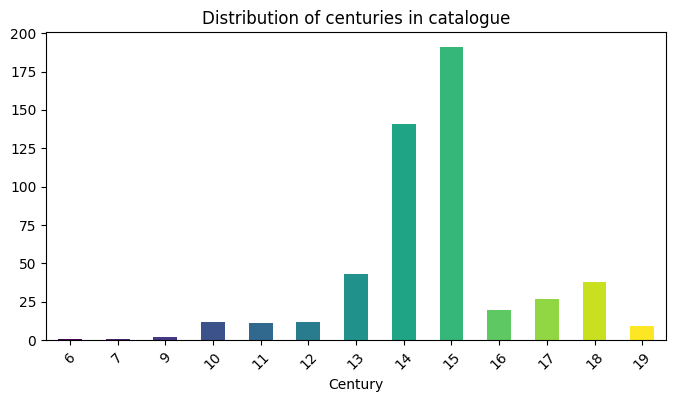

In [24]:
import re

def extract_century(date_str):
    if pd.isna(date_str):
        return None
    
    date_str = str(date_str).lower()

    century_match = re.search(r'(\d+)(?:st|nd|rd|th)\s+century', date_str)
    if century_match:
        return int(century_match.group(1))

    year_match = re.search(r'(\d{3,4})', date_str)
    if year_match:
        year = int(year_match.group(1))
        return (year - 1) // 100 + 1

    return None

df['century'] = df['date'].apply(extract_century)

counts = df['century'].value_counts()

unknown = counts[counts.index == "unknown"]
known = counts[counts.index != "unknown"]

known_sorted = known.copy()
print(known_sorted)

#known_sorted.index = known_sorted.index.str.replace("e", "").astype(float)
known_sorted = known_sorted.sort_index()

final = pd.concat([known_sorted, unknown])

colors = plt.cm.viridis(np.linspace(0, 1, len(final)))


final.plot(kind='bar', color=colors, figsize=(8,4))

plt.title("Distribution of centuries in catalogue")
plt.xlabel("Century")
plt.xticks(rotation=45)
plt.show()